In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.layers import Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import warnings
warnings.filterwarnings("ignore")

In [2]:
MAX_LEN = 470
EPOCHS = 20
BATCH_SIZE = 16

In [4]:
# Load the dataset
train_df = pd.read_csv('rep_features/train_labels.csv')
train_df.head()

,filepath,label
0,rep_features\train\Positives/Blocked\mfcc_What...,1
1,rep_features\train\Positives/Blocked\mfcc_What...,1
2,rep_features\train\Positives/Blocked\mfcc_What...,1
3,rep_features\train\Positives/Blocked\mfcc_What...,1
4,rep_features\train\Positives/Blocked\mfcc_What...,1


In [5]:
train_df.label.value_counts(normalize=True)

label
0    0.869995
1    0.130005
Name: proportion, dtype: float64

In [6]:
val_df = pd.read_csv('rep_features/val_labels.csv')
val_df.head()

,filepath,label
0,rep_features\val\Positives/Blocked\mfcc_WhatsA...,1
1,rep_features\val\Positives/Blocked\mfcc_WhatsA...,1
2,rep_features\val\Positives/Blocked\mfcc_WhatsA...,1
3,rep_features\val\Positives/Blocked\mfcc_WhatsA...,1
4,rep_features\val\Positives/Blocked\mfcc_whatsa...,1


In [7]:
val_df.label.value_counts(normalize=True)

label
0    0.871685
1    0.128315
Name: proportion, dtype: float64

In [8]:
test_df = pd.read_csv('rep_features/test_labels.csv')
test_df.head()

,filepath,label
0,rep_features\test\Positives/Blocked\mfcc_whats...,1
1,rep_features\test\Positives/Blocked\mfcc_Whats...,1
2,rep_features\test\Positives/Blocked\mfcc_Whats...,1
3,rep_features\test\Positives/Blocked\mfcc_Whats...,1
4,rep_features\test\Positives/Blocked\mfcc_Whats...,1


In [9]:
test_df.label.value_counts(normalize=True)

label
0    0.861484
1    0.138516
Name: proportion, dtype: float64

In [10]:
def pad_features(features, max_len=MAX_LEN):
    if features.shape[0] < max_len:
        padding = np.zeros((max_len - features.shape[0], features.shape[1]))
        features = np.vstack((features, padding))
    else:
        features = features[:max_len, :]
    return features

In [11]:
X = []
y = []
for _, row in train_df.iterrows():
    feature = np.load(row["filepath"])
    feature = pad_features(feature)
    X.append(feature)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

In [16]:
X_val = []
y_val = []
for _, row in val_df.iterrows():
    feature = np.load(row["filepath"])
    feature = pad_features(feature)
    X_val.append(feature)
    y_val.append(row["label"])

X_val = np.array(X_val)
y_val = np.array(y_val)

In [19]:
X_test = []
y_test = []
for _, row in test_df.iterrows():
    feature = np.load(row["filepath"])
    feature = pad_features(feature)
    X_test.append(feature)
    y_test.append(row["label"])

X_test = np.array(X_test)
y_test = np.array(y_test)

In [12]:
X.shape, y.shape

((32845, 470, 40), (32845,))

In [17]:
X_val.shape, y_val.shape

((1395, 470, 40), (1395,))

In [20]:
X_test.shape, y_test.shape

((1415, 470, 40), (1415,))

In [14]:
model = Sequential()

model.add(Conv1D(32, kernel_size=5, activation='relu',
                 input_shape=X.shape[1:]))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(Conv1D(64, kernel_size=3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.3))

model.add(GlobalAveragePooling1D())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.4))

model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 466, 32)        │         6,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 466, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 233, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 233, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 231, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 231, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 115, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 115, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,249 (67.38 KB)

 Trainable params: 17,057 (66.63 KB)

 Non-trainable params: 192 (768.00 B)

In [15]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

lr_reduction = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,          # reduce LR by half
    min_lr=1e-6,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    filepath='models/best_repetition_model.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

In [18]:
history = model.fit(
    X, y,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_reduction, model_checkpoint]
)

Epoch 1/20
2052/2053 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9334 - loss: 0.1763
Epoch 1: val_accuracy improved from None to 0.96344, saving model to models/best_repetition_model.keras

Epoch 1: finished saving model to models/best_repetition_model.keras
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 52s 22ms/step - accuracy: 0.9564 - loss: 0.1217 - val_accuracy: 0.9634 - val_loss: 0.1178 - learning_rate: 0.0010
Epoch 2/20
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9712 - loss: 0.0814
Epoch 2: val_accuracy improved from 0.96344 to 0.97849, saving model to models/best_repetition_model.keras

Epoch 2: finished saving model to models/best_repetition_model.keras
2053/2053 ━━━━━━━━━━━━━━━━━━━━ 59s 29ms/step - accuracy: 0.9734 - loss: 0.0759 - val_accuracy: 0.9785 - val_loss: 0.0657 - learning_rate: 0.0010
Epoch 3/20
2051/2053 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9747 - loss: 0.0687
Epoch 3: val_accuracy improved from 0.97849 to 0.98280, saving model to models/best_repetiti

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9845 - loss: 0.0505
Accuracy of our model on test data :  98.44523072242737 %


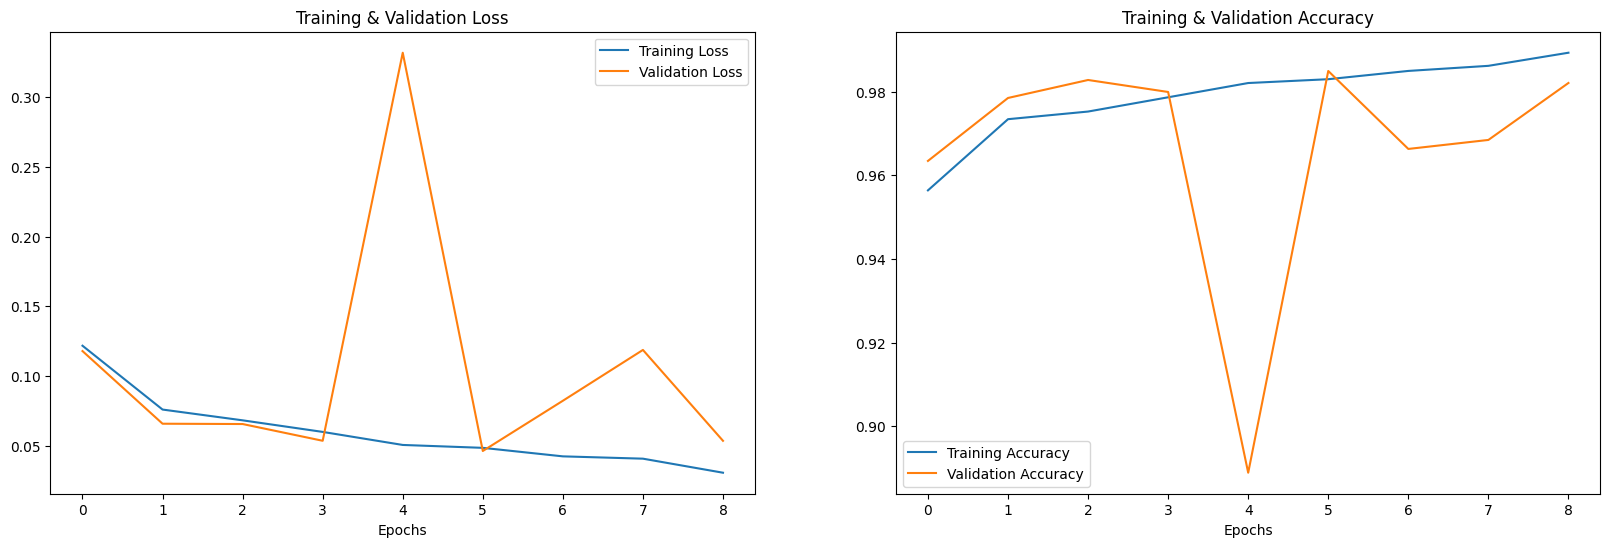

In [21]:
print("Accuracy of our model on test data : " , model.evaluate(X_test, y_test)[1]*100 , "%")

epochs = range(len(history.history['loss']))
fig , ax = plt.subplots(1,2)
train_acc = history.history['accuracy']
train_loss = history.history['loss']
test_acc = history.history['val_accuracy']
test_loss = history.history['val_loss']

fig.set_size_inches(20,6)
ax[0].plot(epochs , train_loss , label = 'Training Loss')
ax[0].plot(epochs , test_loss , label = 'Validation Loss')
ax[0].set_title('Training & Validation Loss')
ax[0].legend()
ax[0].set_xlabel("Epochs")

ax[1].plot(epochs , train_acc , label = 'Training Accuracy')
ax[1].plot(epochs , test_acc , label = 'Validation Accuracy')
ax[1].set_title('Training & Validation Accuracy')
ax[1].legend()
ax[1].set_xlabel("Epochs")
plt.show()

In [22]:
y_pred = model.predict(X_test)

45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


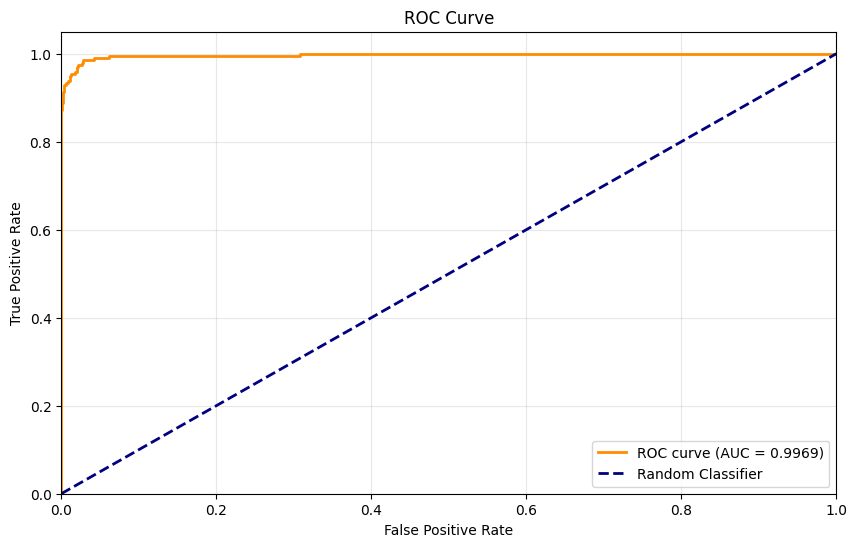

AUC Score: 0.9969


In [23]:
# Calculate ROC curve
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

# Plot ROC curve
plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"AUC Score: {roc_auc:.4f}")

In [24]:
# Method 1: Youden's J statistic (maximize TPR - FPR)
j_scores = tpr - fpr
optimal_idx = np.argmax(j_scores)
optimal_threshold = _[optimal_idx]

print(f"Threshold = {optimal_threshold:.4f} (optimal)")
y_pred_optimal = np.where(y_pred >= optimal_threshold, 1,0).astype(int)
print(f"Accuracy: {accuracy_score(y_test, y_pred_optimal) * 100:.2f}%")

Threshold = 0.0422 (optimal)
Accuracy: 97.39%


In [25]:
print(classification_report(y_test, y_pred_optimal))

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      1219
           1       0.85      0.98      0.91       196

    accuracy                           0.97      1415
   macro avg       0.92      0.98      0.95      1415
weighted avg       0.98      0.97      0.97      1415



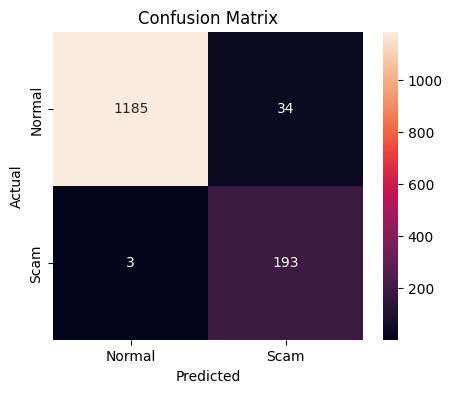

In [26]:
cm = confusion_matrix(y_test, y_pred_optimal)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["Normal","Scam"],
            yticklabels=["Normal","Scam"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [27]:
from tensorflow.keras.models import load_model
model = load_model(r"models\best_repetition_model.keras")

path = r"rep_features\test\Positives\Code\mfcc_WhatsApp Audio 2026-03-06 at 1.36.53 PM_orig.npy"

feature = np.load(path)

In [28]:
feature.shape

(103, 40)

In [29]:
model.predict(np.expand_dims(pad_features(feature), axis=0))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 225ms/step


array([[0.66846514]], dtype=float32)